In [18]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib as mpl

# Load pulses

In [117]:
pulse_par_dir = '../../paper_plots/final_pulses'

files = ["krotov_bad_guess",
         "krotov_good_guess",
         "RL"]

titles = ['Krotov-optimised from bad guess',
         'Krotov-optimised from good guess',
         'RL pulse']

def load_julia_data(fn):
    ext = '.jld2'
    if not fn.endswith(ext):
        fn += ext
        
    with h5py.File(fn, "r") as f:
        J_T = np.array(f['J_T'])
        Δωs1 = np.array(f['Δωs1'])
        Δωs2 = np.array(f['Δωs2'])

    return J_T, Δωs1, Δωs2

def load_pulse(fn):
    ext = '.csv'
    if not fn.endswith(ext):
        fn += ext

    print(f'loading from {fn}')
    data = pd.read_csv(fn)
    amplist = data['amplist'].tolist()
    amplist = np.divide(amplist, np.pi * 2)
    tlist = data['tlist'].tolist()

    return tlist, amplist

cmap_name = 'terrain'
zero_line_c = 'w'
zero_line_lw = 1.2

cmap = mpl.colormaps[cmap_name]
fsz_ticks = 12
fsz_axlbl = 13
fsz_title = 14
plot_inset = True
inset_lbl_c = 'w'
inset_ticklbl_fsz = 7
inset_lbl_fsz = 7

NB_TICKS = 11
ABS_MAX_OMEGA = 50

loading from ../../paper_plots/final_pulses/krotov_bad_guess_pulse.csv
loading from ../../paper_plots/final_pulses/krotov_good_guess_pulse.csv
loading from ../../paper_plots/final_pulses/RL_pulse.csv


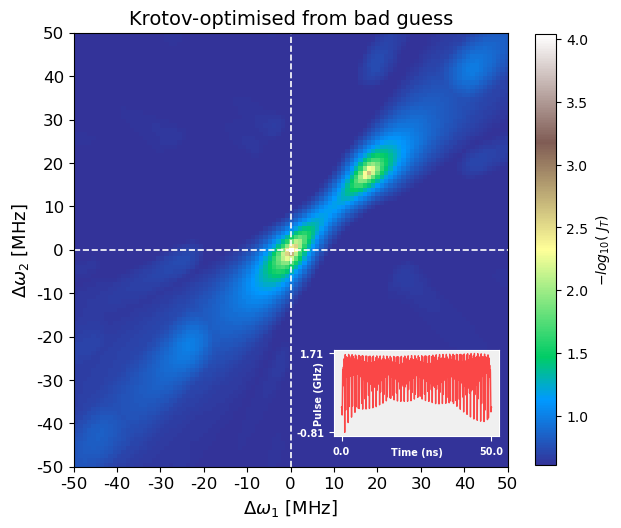

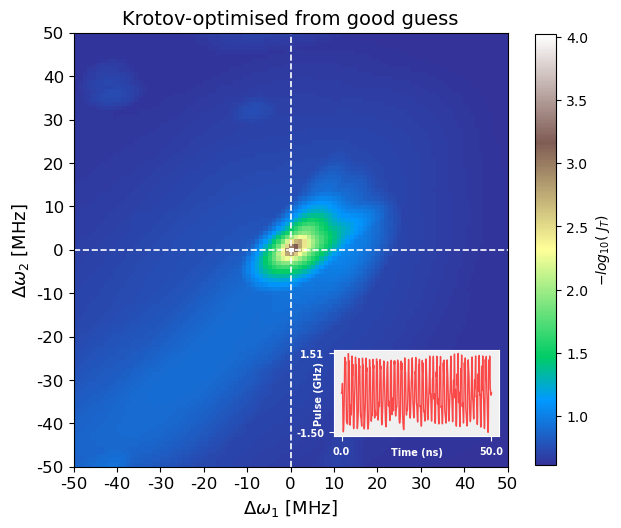

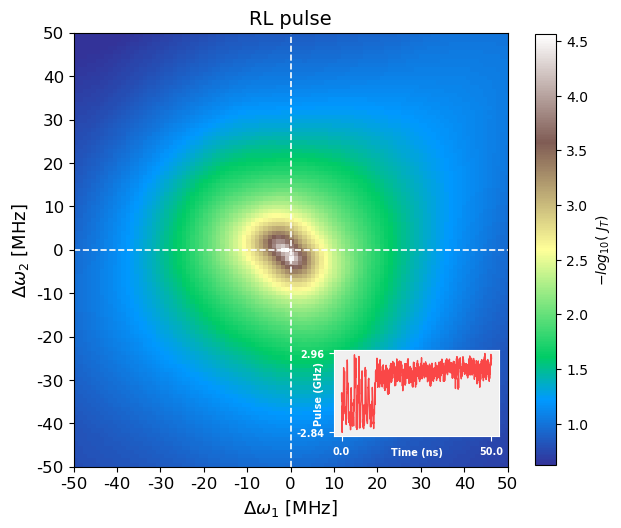

In [118]:
for i, fn in enumerate(files):
    J_T, Δωs1, Δωs2 = load_julia_data(fn)

    pulse_file = os.path.join(pulse_par_dir, fn+'_pulse')
    tlist, amplist = load_pulse(pulse_file)

    xy_ticks = np.linspace(-ABS_MAX_OMEGA, ABS_MAX_OMEGA, NB_TICKS).astype(int)#[0]- ω_1, ω_1_list[-1]- ω_1, 6)
    xytick_labels = [f'{xt:.0f}' for xt in xy_ticks]
    
    x_ticks = xy_ticks
    y_ticks = xy_ticks
    xtick_labels = xytick_labels
    ytick_labels = xytick_labels
    # x_ticks = np.linspace(0, len(Δωs1)-1, NB_TICKS).astype(int)#[0]- ω_1, ω_1_list[-1]- ω_1, 6)
    # y_ticks = np.linspace(0, len(Δωs2)-1, NB_TICKS).astype(int)#[0]- ω_2, ω_2_list[-1]- ω_2, 6)
    # xtick_labels = [f'{(Δωs1[i]):.0f}' for i in x_ticks]
    # ytick_labels = [f'{(Δωs2[i]):.0f}' for i in y_ticks]

    fig, ax = plt.subplots(figsize=(7,7))
    
    heatmap = ax.imshow(-np.log10(J_T), 
                        cmap=cmap, 
                        aspect='equal', 
                        origin='lower',
                        extent=[-ABS_MAX_OMEGA, ABS_MAX_OMEGA, -ABS_MAX_OMEGA, ABS_MAX_OMEGA])
    cbar = fig.colorbar(heatmap, ax=ax, shrink=.8, aspect=20)
    cbar.set_label('$-log_{10}(\,\,J_T)$')
    
    # plt.pcolormesh(Δωs1, Δωs2, np.log10(J_T), cmap=cmap)
    ax.axhline(0.0, c=zero_line_c, lw=zero_line_lw, ls='dashed')
    ax.axvline(0.0, c=zero_line_c, lw=zero_line_lw, ls='dashed')
    
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)

    ax.set_title(titles[i], fontsize=fsz_title)
    ax.set_xticklabels(xtick_labels, fontsize=fsz_ticks)
    ax.set_yticklabels(ytick_labels, fontsize=fsz_ticks)
    ax.set_xlabel(r'$\Delta ω_1$ [MHz]', fontsize=fsz_axlbl)
    ax.set_ylabel(r'$\Delta ω_2$ [MHz]', fontsize=fsz_axlbl)

    if plot_inset:
        # --- Inset Summary Plot (Pulses) ---
        # Create an inset axes in the bottom right corner
        # [x, y, width, height] relative to the parent axes' bounding box
        # x=0.6, y=0.05: starts at 60% from left, 5% from bottom
        # width=0.35, height=0.35: 35% of parent axes width/height
        inset_ax = ax.inset_axes([0.6, 0.07, 0.38, 0.2])
        inset_ax.plot(tlist, amplist, color='red', alpha=0.7, linewidth=1)
    
        # Customize the inset axes for summary appearance
        inset_ax.set_facecolor('#f0f0f0') # Light gray background
    
        # Show final time on x-axis
        inset_ax.set_xticks([tlist[0], tlist[-1]])
        inset_ax.set_xticklabels([f'{tlist[0]:.1f}', f'{tlist[-1]:.1f}'], color=inset_lbl_c)
        inset_ax.tick_params(axis='x', labelsize=7, color=inset_lbl_c) # Smaller font for inset ticks
    
        # Show amplitude min and max on y-axis
        min_amp = np.min(amplist)
        max_amp = np.max(amplist)
        inset_ax.set_yticks([min_amp, max_amp])
        inset_ax.set_yticklabels([f'{min_amp:.2f}', f'{max_amp:.2f}'], color=inset_lbl_c)
        inset_ax.tick_params(axis='y', color=inset_lbl_c) # Smaller font for inset ticks
    
        xticklabels = plt.getp(inset_ax, 'xticklabels')
        yticklabels = plt.getp(inset_ax, 'yticklabels')
        plt.setp(xticklabels, fontsize=inset_ticklbl_fsz, weight='bold')
        plt.setp(yticklabels, fontsize=inset_ticklbl_fsz, weight='bold')
        
        # inset_ax.set_title('Pulses', fontsize=8, loc='left', color='dimgray')
        inset_ax.spines['top'].set_color(inset_lbl_c)    # Remove top spine
        inset_ax.spines['right'].set_color(inset_lbl_c) # Remove right spine
        inset_ax.spines['left'].set_color(inset_lbl_c)
        inset_ax.spines['bottom'].set_color(inset_lbl_c)
    
        # Add labels for clarity
        inset_ax.set_xlabel('Time (ns)', fontsize=inset_lbl_fsz, color=inset_lbl_c, labelpad=-6, fontweight='bold')
        inset_ax.set_ylabel('Pulse (GHz)', fontsize=inset_lbl_fsz, color=inset_lbl_c, labelpad=-20, fontweight='bold')

    fig.savefig(f"{fn}_robustness_{cmap_name}.pdf", bbox_inches='tight')
    # plt.close(fig)